In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris

In [6]:
data = load_iris()

In [7]:
data.data.shape

(150, 4)

In [8]:
print('classes to prsdict :',data.target_names)
print('features:',data.feature_names)

classes to prsdict : ['setosa' 'versicolor' 'virginica']
features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [9]:
x = data.data
y = data.target
display (x.shape,y.shape)

(150, 4)

(150,)

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

In [13]:
xtrain,xtest,ytrain,ytest, = train_test_split(x,y,random_state = 50,
test_size = 0.25)

In [16]:
classifier = DecisionTreeClassifier()
classifier.fit(xtrain,ytrain)
DecisionTreeClassifier()

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [17]:
y_pred = classifier.predict(xtest)

In [19]:
from sklearn.metrics import accuracy_score
print('Accuracy on train data using Gini:',accuracy_score(ytrain,classifier.predict(xtrain)))
print('Accuracy on test data using Gini:',accuracy_score(ytest,y_pred))

Accuracy on train data using Gini: 1.0
Accuracy on test data using Gini: 0.9473684210526315


In [20]:
classifier_entropy = DecisionTreeClassifier(criterion ='entropy')
classifier_entropy.fit(xtrain,ytrain)
y_pred_entropy = classifier_entropy.predict(xtest)
print('Accuracy on train data using entropy',
accuracy_score(ytrain,classifier.predict(xtrain)))
print('Accuracy on test data using entropy',
accuracy_score(ytest,y_pred_entropy))

Accuracy on train data using entropy 1.0
Accuracy on test data using entropy 0.9473684210526315


In [21]:
classifier_entropy1 = DecisionTreeClassifier(criterion = 'entropy',min_samples_split=50)

In [22]:
classifier_entropy1.fit(xtrain,ytrain)
y_pred_entropy1 = classifier_entropy1.predict(xtest)
print('Accuracy on train data using entropy',
accuracy_score(y_true=ytrain, y_pred=
classifier_entropy1.predict(xtrain)))
print('Accuracy on test data using entropy', accuracy_score(y_true =
ytest, y_pred = y_pred_entropy1))

Accuracy on train data using entropy 0.9642857142857143
Accuracy on test data using entropy 0.9473684210526315


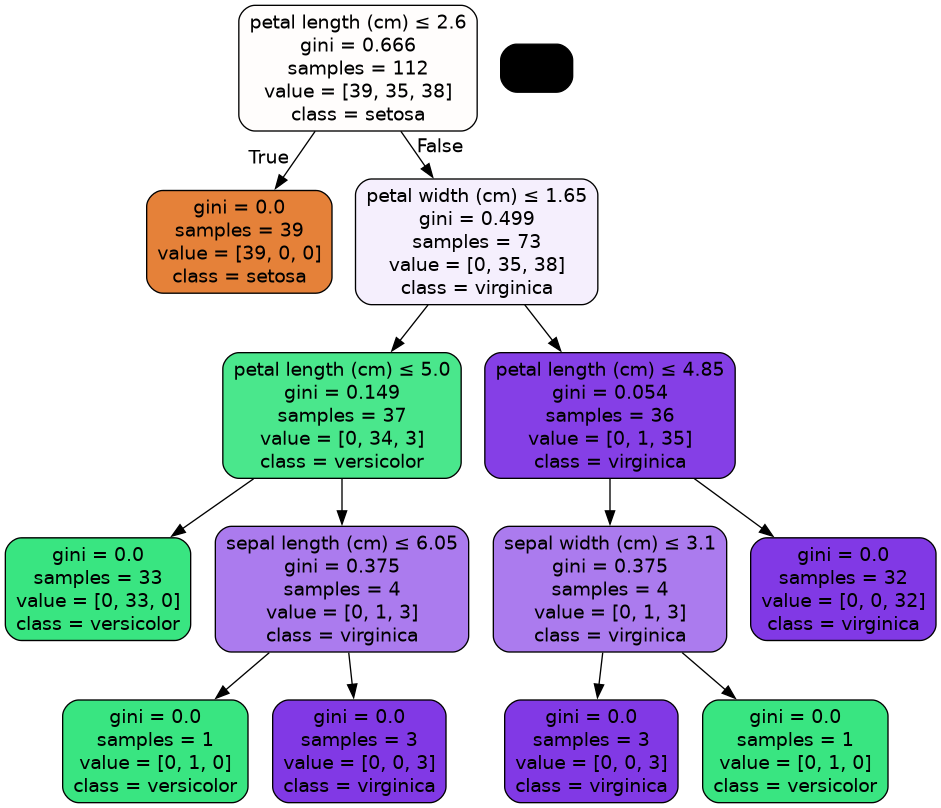

In [36]:
from sklearn.tree import export_graphviz
from six import StringIO
from IPython.display import Image
import pydotplus
dot_data = StringIO()
export_graphviz(classifier, out_file = dot_data, filled = True,rounded = True, special_characters = True, feature_names=data.feature_names, class_names = data.target_names)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())